# 自然语言处理与单词的分布式表示

所谓自然语言就是人们现实世界交往中人们互相交流使用的语言，如汉语、英语、西班牙语等等。自然语言最基本的特点就是人们能听懂。但遗憾的是，机器是怎么也不会懂的，因为机器语言只有冰冷的0和1。那么为了将自然语言转化成机器能听懂的语言，就产生了自然语言处理这么一项技术。自然语言处理最基础的就是词的处理，如何考虑词的分布能更好的让机器学习理解是个很重要的问题。

本章的主题是让计算机理解单词含义。确切地说，我们将探讨一些巧妙地蕴含了单词含义的表示方法。具体来说，本章和下一章将讨论以下3种方法。

- 基于同义词词典的方法（本章）
- 基于计数的方法（本章）
- 基于推理的方法（word2vec） （下一章）

### 同义词词典

回顾自然语言处理的历史，人们已经尝试过很多次类似这样的人工定义单词含义的活动。但是，目前被广泛使用的并不是《新华字典》那样的常规词典，而是一种被称为同义词词典（thesaurus）的词典。在同义词词典中，具有相同含义的单词（同义词）或含义类似的单词（近义词）被归类到同一个组中。比如，使用同义词词典，我们可以知道car的同义词有automobile、motorcar等（图2-1）​。

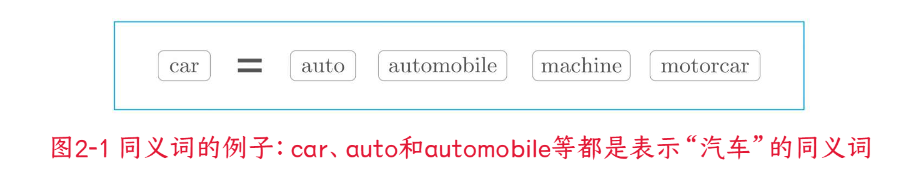

另外，在自然语言处理中用到的同义词词典有时会定义单词之间的粒度更细的关系，比如“上位-下位”关系、​“整体-部分”关系。举个例子，如图2-2所示，我们利用图结构定义了各个单词之间的关系。

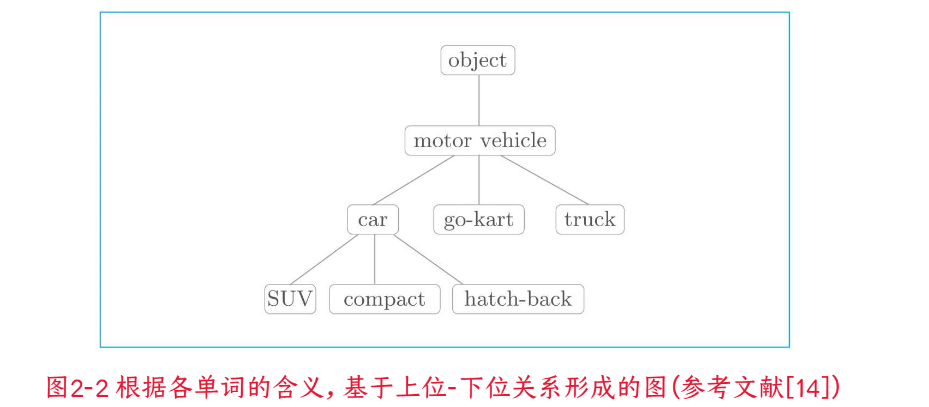

在图2-2中，单词motor vehicle（机动车）是单词car的上位概念。car的下位概念有SUV、compact和hatch-back等更加具体的车种。

像这样，通过对所有单词创建近义词集合，并用图表示各个单词的关系，可以定义单词之间的联系。利用这个“单词网络”​，可以教会计算机单词之间的相关性。也就是说，我们可以将单词含义（间接地）教给计算机，然后利用这一知识，就能让计算机做一些对我们有用的事情。（可想而知，这样做的人工作量巨大。）

### Tip:如何使用同义词词典

根据自然语言处理的具体应用的不同而不同。比如，在信息检索场景中，如果事先知道automobile和car是近义词，就可以将automobile的检索结果添加到car的检索结果中。

### Tip:WordNet

在自然语言处理领域，最著名的同义词词典是WordNet。WordNet是普林斯顿大学于1985年开始开发的同义词词典，迄今已用于许多研究，并活跃于各种自然语言处理应用中。使用WordNet，可以获得单词的近义词，或者利用单词网络。使用单词网络，可以计算单词之间的相似度。

### Tip:同义词词典的问题

WordNet等同义词词典中对大量单词定义了同义词和层级结构关系等。利用这些知识，可以（间接地）让计算机理解单词含义。不过，人工标记也存在一些较大的缺陷。下面，我们就来看一下同义词词典的主要问题，并分别对其进行简要说明。

- 难以顺应时代变化

    我们使用的语言是活的。随着时间的推移，新词不断出现，而那些落满尘埃的旧词不知哪天就会被遗忘。比如，​“众筹”​（crowdfunding）就是一个最近才开始使用的新词。
    
    另外，语言的含义也会随着时间的推移而变化。比如，英语中的heavy一词，现在有“事态严重”的含义（主要用作俚语）​，但以前是没有这种用法的。在电影《回到未来》中，有这样一个场景：从1985年穿越回来的马蒂和生活在1955年的博士的对话中，对heavy的含义有不同的理解。如果要处理这样的单词变化，就需要人工不停地更新同义词词典。

- 人力成本高

    制作词典需要巨大的人力成本。以英文为例，据说现有的英文单词总数超过1000万个。在极端情况下，还需要对如此大规模的单词进行单词之间的关联。顺便提一下，WordNet中收录了超过20万个的单词。

- 无法表示单词的微妙差异

    同义词词典中将含义相近的单词作为近义词分到一组。但实际上，即使是含义相近的单词，也有细微的差别。比如，vintage和retro虽然表示相同的含义，但是用法不同，而这种细微的差别在同义词词典中是无法表示出来的（让人来解释是相当困难的）​。

不仅限于自然语言处理，在图像识别领域，多年来也一直是人工设计特征量。但是，随着深度学习的出现，现在从原始图像直接获得最终结果已成为可能，人为介入的必要性大幅降低。在自然语言处理领域也有类似现象。也就是说，我们正在从人工制作词典或设计特征量的旧范式，向尽量减少人为干预的、仅从文本数据中获取最终结果的新范式转移。

### 基于计数的方法

从介绍基于计数的方法开始，我们将使用语料库（corpus）​。简而言之，语料库就是大量的文本数据。不过，语料库并不是胡乱收集数据，一般收集的都是用于自然语言处理研究和应用的文本数据。

说到底，语料库只是一些文本数据而已。不过，其中的文章都是由人写出来的。换句话说，语料库中包含了大量的关于自然语言的实践知识，即文章的写作方法、单词的选择方法和单词含义等。基于计数的方法的目标就是从这些富有实践知识的语料库中，自动且高效地提取本质。

### Tip:语料库

自然语言处理领域中使用的语料库有时会给文本数据添加额外的信息。比如，可以给文本数据的各个单词标记词性。在这种情况下，为了方便计算机处理，语料库通常会被结构化（比如，采用树结构等数据形式）​。这里，假定我们使用的语料库没有添加标签，而是作为一个大的文本文件，只包含简单的文本数据。

### 基于Pyhton的语料库的预处理

自然语言处理领域存在各种各样的语料库。说到有名的语料库，有Wikipedia和Google News等。另外，莎士比亚、夏目漱石等伟大作家的作品集也会被用作语料库。本章我们先使用仅包含一个句子的简单文本作为语料库，然后再处理更实用的语料库。

现在，我们使用Python的交互模式，对一个非常小的文本数据（语料库）进行预处理。这里所说的预处理是指，将文本分割为单词（分词）​，并将分割后的单词列表转化为单词ID列表。下面，我们一边确认一边实现。首先来看一下作为语料库的样本文章。

下面，我们一边确认一边实现。首先来看一下作为语料库的样本文章。

In [8]:
text = 'Your say goodbye and I say hello.'

这里我们使用由单个句子构成的文本作为语料库。本来文本（text）应该包含成千上万个（连续的）句子，但是，考虑到简洁性，这里先对这个小的文本数据进行预处理。下面，我们对上面的text进行分词。

In [10]:
text = text.lower()
text = text.replace('.',' .')
text

'your say goodbye and i say hello .'

In [11]:
words = text.split(' ')
words

['your', 'say', 'goodbye', 'and', 'i', 'say', 'hello', '.']

首先，使用lower（​）方法将所有字母转化为小写，这样可以将句子开头的单词也作为常规单词处理。然后，将空格作为分隔符，通过split（' '）切分句子。考虑到句子结尾处的句号（.）​，我们先在句号前插入一个空格（即用“ .”替换“.”​）​，再进行分词。

### Tip:分词

这里，在进行分词时，我们采用了一种在句号前插入空格的“临时对策”​，其实还有更加聪明、更加通用的实现方式，比如使用正则表达式。通过导入正则表达式的re模块，使用re.split（'（\W+）?', text）也可以进行分词。

现在，我们已经可以将原始文章作为单词列表使用了。虽然分词后文本更容易处理了，但是直接以文本的形式操作单词，总感觉有些不方便。因此，我们进一步给单词标上ID，以便使用单词ID列表。为此，我们使用Python的字典来创建单词ID和单词的对应表。

In [12]:
word_to_id = {}
id_to_word = {}

for word in words:
    if word not in word_to_id:
        new_id = len(word_to_id)
        word_to_id[word] = new_id
        id_to_word[new_id] = word


变量id_to_word负责将单词ID转化为单词（键是单词ID，值是单词）, word_to_id负责将单词转化为单词ID。这里，我们从头开始逐一观察分词后的words的各个元素，如果单词不在word_to_id中，则分别向word_to_id和id_to_word添加新ID和单词。另外，我们将字典的长度设为新的单词ID，单词ID按0, 1, 2,···逐渐增加。

这样一来，我们就创建好了单词ID和单词的对应表。下面，我们来实际看一下它们的内容。

In [13]:
id_to_word

{0: 'your', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}

In [14]:
word_to_id

{'your': 0, 'say': 1, 'goodbye': 2, 'and': 3, 'i': 4, 'hello': 5, '.': 6}

使用这些词典，可以根据单词检索单词ID，或者反过来根据单词ID检索单词。我们实际尝试一下，如下所示。

In [18]:
word_to_id['hello']

5

In [19]:
id_to_word[5]

'hello'

最后，我们将单词列表转化为单词ID列表。这里，我们使用Python的列表解析式将单词列表转化为单词ID列表，然后再将其转化为NumPy数组。

In [20]:
import numpy as np

corpus = [word_to_id[w] for w in words]
corpus = np.array(corpus)
corpus

array([0, 1, 2, 3, 4, 1, 5, 6])

### Tip:列表解析式（list comprehension）

或字典解析式（dict comprehension）是一种便于对列表或字典进行循环处理的写法。比如，要创建元素为列表xs = [1,2,3,4]中各个元素的平方的新列表，可以写成 [x**2 for x in xs]​。

至此，我们就完成了利用语料库的准备工作。现在，我们将上述一系列处理实现为preprocess（​）函数

In [22]:
def preprocess(text):
    text = text.lower()
    text = text.replace('.',' .')
    words = text.split(' ')

    word_to_id = {}
    id_to_word = {}
    for word in words:
        if word not in word_to_id:
            new_id = len(word_to_id)
            word_to_id[word] = new_id
            id_to_word[new_id] = word
    corpus = np.array([word_to_id[w] for w in words])

    return corpus,word_to_id,id_to_word

In [23]:
text = "I love you, you love him."
corpus,word_to_id,id_to_word = preprocess(text)

In [24]:
corpus,word_to_id,id_to_word

(array([0, 1, 2, 3, 1, 4, 5]),
 {'i': 0, 'love': 1, 'you,': 2, 'you': 3, 'him': 4, '.': 5},
 {0: 'i', 1: 'love', 2: 'you,', 3: 'you', 4: 'him', 5: '.'})

到这里，语料库的预处理就结束了。这里准备的corpus、word_to_id和id_to_word这3个变量名在本书接下来的很多地方都会用到。corpus是单词ID列表，word_to_id是单词到单词ID的字典，id_to_word是单词ID到单词的字典。现在，我们已经做好了操作语料库的准备，接下来的目标就是使用语料库提取单词含义。为此，本节我们将考察基于计数的方法。采用这种方法，我们能够将单词表示为向量。

### 对于单词的分布式表示的一个良好的解释

世界上存在各种各样的颜色，有的颜色被赋予了固定的名字，比如钴蓝（cobalt blue）或者锌红（zinc red）​；颜色也可以通过RGB（Red/Green/Blue）三原色分别存在多少来表示。前者为不同的颜色赋予不同的名字，有多少种颜色，就需要有多少个不同的名字；后者则将颜色表示为三维向量。

需要注意的是，使用RGB这样的向量表示可以更准确地指定颜色，并且这种基于三原色的表示方式很紧凑，也更容易让人想象到具体是什么颜色。比如，即便不知道“深绯”是什么样的颜色，但如果知道它的（R, G, B）=（201, 23, 30）​，就至少可以知道它是红色系的颜色。此外，颜色之间的关联性（是否是相似的颜色）也更容易通过向量表示来判断和量化。

那么，能不能将类似于颜色的向量表示方法运用到单词上呢？更准确地说，可否在单词领域构建紧凑合理的向量表示呢？接下来，我们将关注能准确把握单词含义的向量表示。在自然语言处理领域，这称为分布式表示。

### Tip:单词的分布式表示

将单词表示为固定长度的向量。这种向量的特征在于它是用密集向量表示的。密集向量的意思是，向量的各个元素（大多数）是由非0实数表示的。例如，三维分布式表示是[0.21,-0.45,0.83]​。如何构建这样的单词的分布式表示是我们接下来的一个重要课题。

### 分布式假设

在自然语言处理的历史中，用向量表示单词的研究有很多。如果仔细看一下这些研究，就会发现几乎所有的重要方法都基于一个简单的想法，这个想法就是“某个单词的含义由它周围的单词形成”​，称为分布式假设（distributional hypothesis）​。许多用向量表示单词的近期研究也基于该假设。分布式假设所表达的理念非常简单。单词本身没有含义，单词含义由它所在的上下文（语境）形成。的确，含义相同的单词经常出现在相同的语境中。比如“I drink beer.”​“We drink wine.”,drink的附近常有饮料出现。另外，从“I guzzle beer.”​“We guzzle wine.”可知，guzzle和drink所在的语境相似。进而我们可以推测出，guzzle和drink是近义词（顺便说一下，guzzle是“大口喝”的意思）​。从现在开始，我们会经常使用“上下文”一词。本章说的上下文是指某个单词（关注词）周围的单词。在图2-3的例子中，左侧和右侧的2个单词就是上下文。

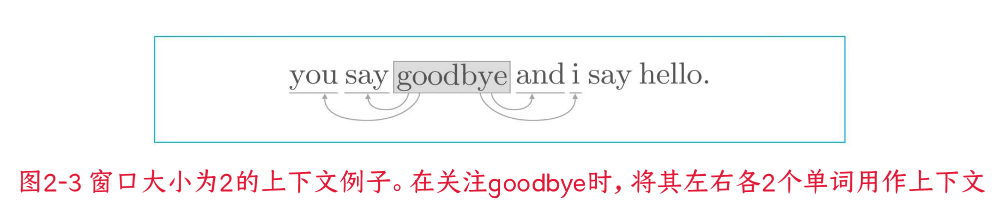

如图2-3所示，上下文是指某个居中单词的周围词汇。这里，我们将上下文的大小（即周围的单词有多少个）称为窗口大小（window size）​。窗口大小为1，上下文包含左右各1个单词；窗口大小为2，上下文包含左右各2个单词，以此类推。

这里，我们将左右两边相同数量的单词作为上下文。但是，根据具体情况，也可以仅将左边的单词或者右边的单词作为上下文。此外，也可以使用考虑了句子分隔符的上下文。简单起见，本书仅处理不考虑句子分隔符、左右单词数量相同的上下文。

### 共现矩阵

下面，我们来考虑如何基于分布式假设使用向量表示单词，最直截了当的实现方法是对周围单词的数量进行计数。具体来说，在关注某个单词的情况下，对它的周围出现了多少次什么单词进行计数，然后再汇总。这里，我们将这种做法称为“基于计数的方法”​，在有的文献中也称为“基于统计的方法”​。

现在，我们就来看一下基于计数的方法。这里我们使用之前的语料库和preprocess（​）函数，再次进行预处理。

In [1]:
import sys
sys.path.append('..')
import numpy as np

from common.util import preprocess

text = 'You say goodbye and I say hello.'
corpus,word_to_id,id_to_word = preprocess(text)

print(corpus)
print(id_to_word)
print(word_to_id)

[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}
{'you': 0, 'say': 1, 'goodbye': 2, 'and': 3, 'i': 4, 'hello': 5, '.': 6}


从上面的结果可以看出，词汇总数为7个。下面，我们计算每个单词的上下文所包含的单词的频数。在这个例子中，我们将窗口大小设为1，从单词ID为0的you开始。从图2-4可以清楚地看到，单词you的上下文仅有say这个单词。用表格表示的话，如图2-5所示。

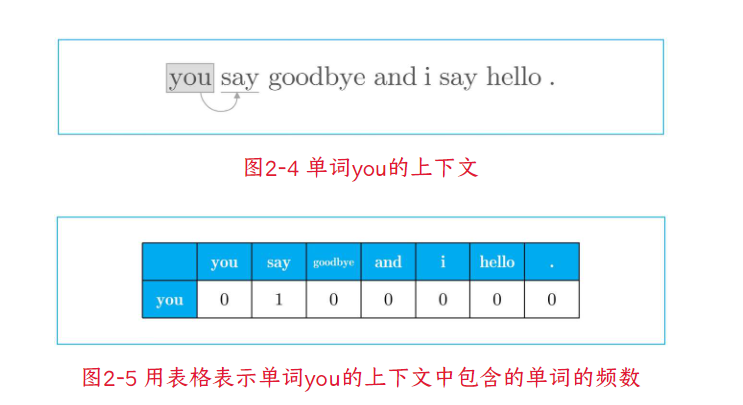

图2-5表示的是作为单词you的上下文共现的单词的频数。同时，这也意味着可以用向量[0, 1, 0, 0, 0, 0, 0]表示单词you。

接着对单词ID为1的say进行同样的处理，结果如图2-6所示。

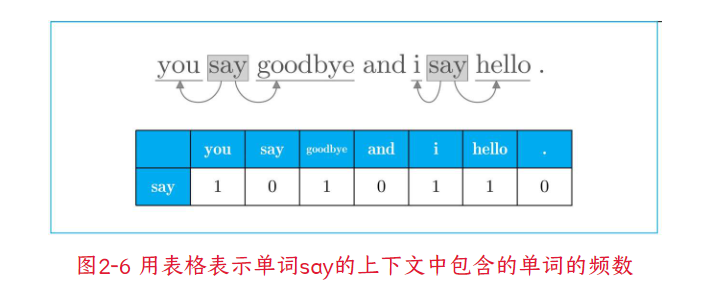

从上面的结果可知，单词say可以表示为向量[1, 0, 1, 0, 1, 1, 0]​。对所有的7个单词进行上述操作，会得到如图2-7所示的结果。

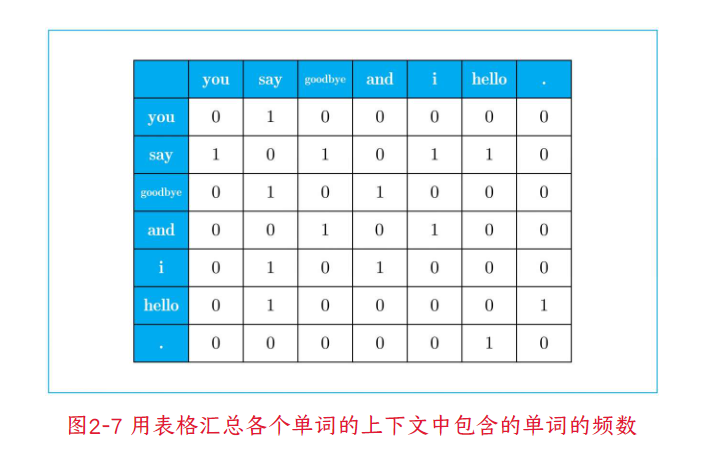

图2-7是汇总了所有单词的共现单词的表格。这个表格的各行对应相应单词的向量。因为图2-7的表格呈矩阵状，所以称为共现矩阵（co-occurence matrix）​。

接下来，我们来实际创建一下上面的共现矩阵。这里，将图2-7的结果按原样手动输入。

In [2]:
C = np.array([
    [0, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 0],
    [0, 1, 0, 1, 0, 0, 0],
    [0, 0, 1, 0, 1, 0, 0],
    [0, 1, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 1, 0],
    ], dtype=np.int32)


这就是共现矩阵。使用这个共现矩阵，可以获得各个单词的向量，如下所示。

In [3]:
print(C[0])# 单词ID为0的向量

[0 1 0 0 0 0 0]


In [4]:
print(C[4])

[0 1 0 1 0 0 0]


In [5]:
print(C[word_to_id['goodbye']])# goodbye的向量

[0 1 0 1 0 0 0]


至此，我们通过共现矩阵成功地用向量表示了单词。上面我们是手动输入共现矩阵的，但这一操作显然可以自动化。下面，我们来实现一个能直接从语料库生成共现矩阵的函数。我们把这个函数称为create_co_matrix（corpus, vocab_size, window_size=1）​，其中参数corpus是单词ID列表，参数vocab_size是词汇个数，window_size是窗口大小

In [7]:
def create_co_matrix(corpus,vocab_size,window_size=1):
    corpus_size = len(corpus)
    co_matrix = np.zeros((vocab_size,vocab_size),dtype=np.int32)
    for idx,word_id in enumerate(corpus):
        for i in range(1,window_size+1):
            left_idx = idx - i
            right_idx = idx + i

            if left_idx >= 0:
                left_word_id = corpus[left_idx]
                co_matrix[word_id,left_word_id] += 1
            
            if right_idx < corpus_size:
                right_word_id = corpus[right_idx]
                co_matrix[word_id,right_word_id] += 1
    
    return co_matrix

首先，用元素为0的二维数组对co_matrix进行初始化。然后，针对语料库中的每一个单词，计算它的窗口中包含的单词。同时，检查窗口内的单词是否超出了语料库的左端和右端。这样一来，无论语料库多大，都可以自动生成共现矩阵。之后，我们都将使用这个函数生成共现矩阵。

### 向量间的相似度

测量向量间的相似度有很多方法，其中具有代表性的方法有向量内积或欧式距离等。虽然除此之外还有很多方法，但是在测量单词的向量表示的相似度方面，余弦相似度（cosine similarity）是很常用的。设有x=（x1, x2, x3,···, xn）和y=（y1, y2, y3,···, yn）两个向量，它们之间的余弦相似度的定义如下式所示。

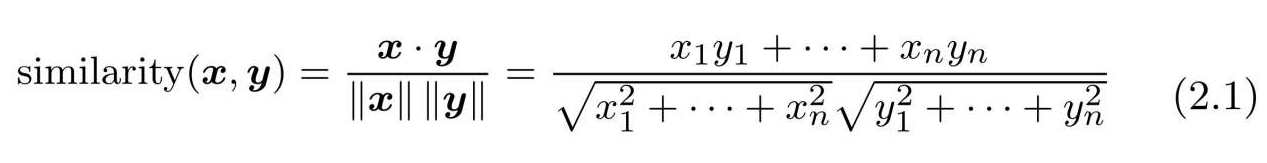

在式（2.1）中，分子是向量内积，分母是各个向量的范数。范数表示向量的大小，这里计算的是L2范数（即向量各个元素的平方和的平方根）​。式（2.1）的要点是先对向量进行正规化，再求它们的内积。

### Tip:余弦相似度

余弦相似度直观地表示了“两个向量在多大程度上指向同一方向”​。两个向量完全指向相同的方向时，余弦相似度为1；完全指向相反的方向时，余弦相似度为-1。

现在，我们来实现余弦相似度。基于式（2.1）​，代码如下所示。

In [6]:
def cos_similarity(x,y):
    nx = x / np.sqrt(np.sum(x**2))# x的正规化
    ny = y / np.sqrt(np.sum(y**2))# y的正规化
    return np.dot(nx,ny)

这里，我们假定参数x和y是NumPy数组。首先对向量进行正规化，然后求两个向量的内积。这里余弦相似度的实现虽然完成了，但是还有一个问题。那就是当零向量（元素全部为0的向量）被赋值给参数时，会出现“除数为0”​（zero division）的错误。

解决此类问题的一个常用方法是，在执行除法时加上一个微小值。这里，通过参数指定一个微小值eps（eps是epsilon的缩写）​，并默认eps=1e-8（=0.00000001）​。这样修改后的余弦相似度的实现如下所示

In [8]:
def cos_similarity(x,y,eps=1e-8):
    nx = x / (np.sqrt(np.sum(x**2))+eps)
    ny = y / (np.sqrt(np.sum(y**2))+eps)
    return np.dot(nx,ny)

### Tip:1e-8

这里我们用了1e-8作为微小值，在这么小的值的情况下，根据浮点数的舍入误差，这个微小值会被其他值“吸收”掉。在上面的实现中，因为这个微小值会被向量的范数“吸收”掉，所以在绝大多数情况下，加上eps不会对最终的计算结果造成影响。而当向量的范数为0时，这个微小值可以防止“除数为0”的错误。

利用这个函数，可以如下求得单词向量间的相似度。这里，我们尝试求you和i（=I）的相似度

In [9]:
import sys
sys.path.append('..')
from common.util import preprocess,create_co_matrix,cos_similarity

text = 'You say goodbye and I say hello.'
corpus,word_to_id,id_to_word = preprocess(text)
vocab_size = len(word_to_id)
C = create_co_matrix(corpus,vocab_size)

c0 = C[word_to_id['you']]# you的单词向量
c1 = C[word_to_id['i']]# i的单词向量
print(cos_similarity(c0,c1))

0.7071067691154799


从上面的结果可知，you和i的余弦相似度是0.70...。由于余弦相似度的取值范围是-1到1，所以可以说这个值是相对比较高的（存在相似性）​。

### 相似单词的排序



余弦相似度已经实现好了，使用这个函数，我们可以实现另一个便利的函数：当某个单词被作为查询词时，将与这个查询词相似的单词按降序显示出来。这里将这个函数称为most_similar（​）​，通过下列参数进行实现（表2-1）​。

        most_similar（query, word_to_id, id_to_word, word_matrix, top=5）


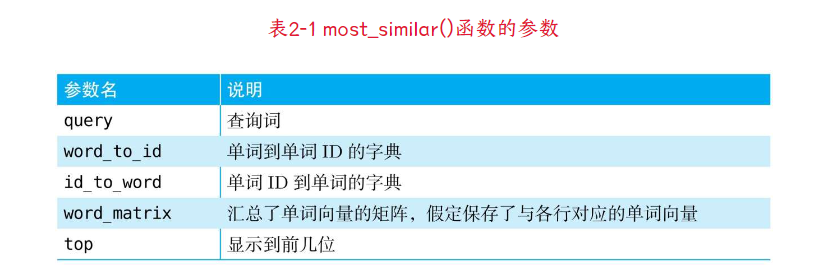

In [11]:
def most_similar(query,word_to_id,id_to_word,word_matrix,top=5):
    
    # ①取出查询词
    if query not in word_to_id:
        print('%s is not found' % query)
        return
    print('\n[query] ' + query)
    query_id = word_to_id[query]

    query_vec = word_matrix[query_id]

    # ②计算余弦相似度
    vocab_size = len(id_to_word)
    similarity = np.zeros(vocab_size)
    for i in range(vocab_size):
        similarity[i] = cos_similarity(word_matrix[i], query_vec)

    # ③基于余弦相似度，按降序输出值
    count = 0
    for i in (-1 * similarity).argsort():
        if id_to_word[i] == query:
            continue
        print (' %s: %s' % (id_to_word[i], similarity[i]))
        count += 1
        if count >= top:
            return

上述实现按如下顺序执行。
- 取出查询词的单词向量。
- 分别求得查询词的单词向量和其他所有单词向量的余弦相似度。
- 基于余弦相似度的结果，按降序显示它们的值。

我们仅对步骤③进行补充说明。在步骤③中，将similarity数组中的元素索引按降序重新排列，并输出顶部的单词。这里使用argsort（​）方法对数组的索引进行了重排。这个argsort（​）方法可以按升序对NumPy数组的元素进行排序（不过，返回值是数组的索引）​。下面是一个例子。

In [12]:
x = np.array([100,-20,2])
x.argsort()

array([1, 2, 0], dtype=int64)

上述代码对NumPy数组[100,-20, 2]的各个元素按升序进行了排列。此时，返回的数组的各个元素对应原数组的索引。上述结果的顺序是“第1个元素（-20）​”​“第2个元素（2）​”​“第0个元素（100）​”​。现在我们想做的是将单词的相似度按降序排列，因此，将NumPy数组的各个元素乘以-1后，再使用argsort（​）方法。接着上面的例子，有如下代码。

In [13]:
(-x).argsort()

array([0, 2, 1], dtype=int64)

使用这个argsort（​）​，可以按降序输出单词相似度。以上就是most_similar（​）函数的实现，下面我们来试着使用一下。这里将you作为查询词，显示与其相似的单词，代码如下所示

In [16]:
import sys
sys.path.append('..')
from common.util import preprocess,create_co_matrix,most_similar

# text = 'You love me,I love you.'
text = 'You say goodbye and I say hello.'

corpus,word_to_id,id_to_word = preprocess(text)
vocab_size = len(word_to_id)
C = create_co_matrix(corpus,vocab_size)

most_similar('you',word_to_id,id_to_word,C,top=5)


[query] you
 goodbye: 0.7071067691154799
 i: 0.7071067691154799
 hello: 0.7071067691154799
 say: 0.0
 and: 0.0


这个结果只按降序显示了you这个查询词的前5个相似单词，各个单词旁边的值是余弦相似度。观察上面的结果可知，和you最接近的单词有3个，分别是goodbye、i（=I）和hello。因为i和you都是人称代词，所以二者相似可以理解。但是，goodbye和hello的余弦相似度也很高，这和我们的感觉存在很大的差异。一个可能的原因是，这里的语料库太小了。后面我们会用更大的语料库进行相同的实验。

如上所述，我们通过共现矩阵成功地将单词表示为了向量。至此，基于计数的方法的基本内容就介绍完了。之所以说“基本”​，是因为还有许多事情需要讨论。下一节，我们将说明当前方法的改进思路，并实现这个改进思路。

### 基于计数方法的改进

上节介绍的基于计数的方法实际上就是想要引出“共现矩阵”这种文本向量的分布式表示方式，但是，这个共现矩阵还有许多可以改进的地方。本节我们将对其进行改进，并使用更实用的语料库，获得单词的“真实的”分布式表示。

### 点互信息

比如，我们来考虑某个语料库中the和car共现的情况。在这种情况下，我们会看到很多“...the car...”这样的短语。因此，它们的共现次数将会很大。另外，car和drive也明显有很强的相关性。但是，如果只看单词的出现次数，那么与drive相比，the和car的相关性更强。这意味着，仅仅因为the是个常用词，它就被认为与car有很强的相关性。

为了解决这一问题，可以使用点互信息（Pointwise Mutual Information, PMI）这一指标。对于随机变量x和y，它们的PMI定义如下（关于概率，将在3.5.1节详细说明）​：

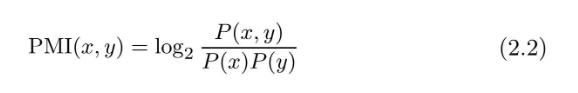

其中，P（x）表示x发生的概率，P（y）表示y发生的概率，P（x, y）表示x和y同时发生的概率。PMI的值越高，表明相关性越强。

在自然语言的例子中，P（x）就是指单词x在语料库中出现的概率。假设某个语料库中有10000个单词，其中单词the出现了100次，则P（"the"）=100/10000=0.01。另外，P（x, y）表示单词x和y同时出现的概率。假设the和car一起出现了10次，则10/10000=0.001。

现在，我们使用共现矩阵（其元素表示单词共现的次数）来重写式（2.2）​。这里，将共现矩阵表示为C，将单词x和y的共现次数表示为C（x, y）​，将单词x和y的出现次数分别表示为C（x）​、C（y）​，将语料库的单词数量记为N，则式（2.2）可以重写为：

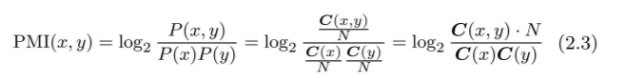

根据式（2.3）​，可以由共现矩阵求PMI。下面我们来具体地算一下。这里假设语料库的单词数量（N）为10000,the出现100次，car出现20次， drive出现10次，the和car共现10次，car和drive共现5次。这时，如果从共现次数的角度来看，则与drive相比，the和car的相关性更强。而如果从PMI的角度来看，结果是怎样的呢？我们来计算一下。

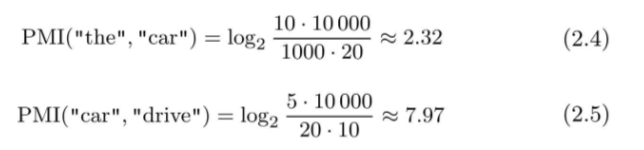

结果表明，在使用PMI的情况下，与the相比，drive和car具有更强的相关性。这是我们想要的结果。之所以出现这个结果，是因为我们考虑了单词单独出现的次数。在这个例子中，因为the本身出现得多，所以PMI的得分被拉低了。式中的“≈”​（near equal）表示近似相等的意思。

虽然我们已经获得了PMI这样一个好的指标，但是PMI也有一个问题。那就是当两个单词的共现次数为0时，log20=-∞。为了解决这个问题，实践上我们会使用下述正的点互信息（Positive PMI,PPMI）​。

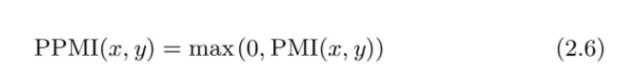

根据式（2.6）​，当PMI是负数时，将其视为0，这样就可以将单词间的相关性表示为大于等于0的实数。下面，我们来实现将共现矩阵转化为PPMI矩阵的函数。我们把这个函数称为ppmi（C, verbose=False, eps=1e-8）

In [2]:
def ppmi(C, verbose=False, eps=1e-8):
    M = np.zeros_like(C, dtype=np.float32)
    N = np.sum(C)
    S = np.sum(C, axis=0)
    total = C.shape[0] * C.shape[1]
    cnt = 0

    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            pmi = np.log2(C[i, j] * N / (S[j]*S[i]) + eps)
            M[i, j] = max(0, pmi)

            if verbose:
                cnt += 1
                if cnt % (total//100+1) == 0:
                    print ('%.1f%% done' % (100*cnt/total))
    return M

这里，参数C表示共现矩阵，verbose是决定是否输出运行情况的标志。当处理大语料库时，设置verbose=True，可以用于确认运行情况。在这段代码中，为了仅从共现矩阵求PPMI矩阵而进行了简单的实现。具体来说，当单词x和y的共现次数为C（x, y）时，[插图],[插图],[插图]，进行这样近似并实现。另外，在上述代码中，为了防止np.log2（0）=-inf而使用了微小值eps。

### Tip:eps

在2.3.5节中，为了防止“除数为0”的错误，我们给分母添加了一个微小值。这里也一样，通过将np.log（x）改为np.log（x + eps）​，可以防止对数运算发散到负无穷大。

现在将共现矩阵转化为PPMI矩阵，可以像下面这样进行实现

In [3]:
import sys
sys.path.append('..')
import numpy as np
from common.util import preprocess, create_co_matrix, cos_similarity, ppmi

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(word_to_id)
C = create_co_matrix(corpus, vocab_size)
W = ppmi(C)

np.set_printoptions(precision=3) # 有效位数为3位
print ('covariance matrix')
print (C)
print ('-'*50)
print ('PPMI')
print (W)


covariance matrix
[[0 1 0 0 0 0 0]
 [1 0 1 0 1 1 0]
 [0 1 0 1 0 0 0]
 [0 0 1 0 1 0 0]
 [0 1 0 1 0 0 0]
 [0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0]]
--------------------------------------------------
PPMI
[[0.    1.807 0.    0.    0.    0.    0.   ]
 [1.807 0.    0.807 0.    0.807 0.807 0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.    1.807 0.    1.807 0.    0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.807 0.    0.    0.    0.    2.807]
 [0.    0.    0.    0.    0.    2.807 0.   ]]


这样一来，我们就将共现矩阵转化为了PPMI矩阵。此时，PPMI矩阵的各个元素均为大于等于0的实数。我们得到了一个由更好的指标形成的矩阵，这相当于获取了一个更好的单词向量。

但是，这个PPMI矩阵还是存在一个很大的问题，那就是随着语料库的词汇量增加，各个单词向量的维数也会增加。如果语料库的词汇量达到10万，则单词向量的维数也同样会达到10万。实际上，处理10万维向量是不现实的。

另外，如果我们看一下这个矩阵，就会发现其中很多元素都是0。这表明向量中的绝大多数元素并不重要，也就是说，每个元素拥有的“重要性”很低。另外，这样的向量也容易受到噪声影响，稳健性差。对于这些问题，一个常见的方法是向量降维。

### 降维

所谓降维（dimensionality reduction）​，顾名思义，就是减少向量维度。但是，并不是简单地减少，而是在尽量保留“重要信息”的基础上减少。如图2-8所示，我们要观察数据的分布，并发现重要的“轴”​。

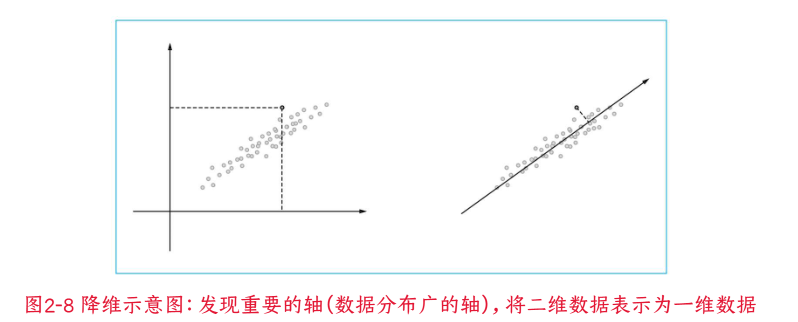

在图2-8中，考虑到数据的广度，导入了一根新轴，以将原来用二维坐标表示的点表示在一个坐标轴上。此时，用新轴上的投影值来表示各个数据点的值。这里非常重要的一点是，选择新轴时要考虑数据的广度。如此，仅使用一维的值也能捕获数据的本质差异。在多维数据中，也可以进行同样的处理。

### Tip：稀疏矩阵降维
向量中的大多数元素为0的矩阵（或向量）称为稀疏矩阵（或稀疏向量）​。这里的重点是，从稀疏向量中找出重要的轴，用更少的维度对其进行重新表示。结果，稀疏矩阵就会被转化为大多数元素均不为0的密集矩阵。这个密集矩阵就是我们想要的单词的分布式表示。

### 奇异值分解

降维的方法有很多，这里我们使用奇异值分解（Singular Value Decomposition,SVD）​。SVD将任意矩阵分解为3个矩阵的乘积，如下式所示：
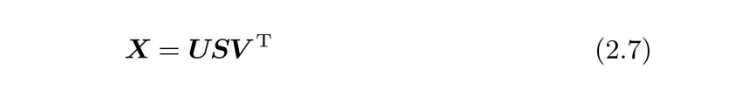



如式（2.7）所示，SVD将任意的矩阵X分解为U、S、V这3个矩阵的乘积，其中U和V是列向量彼此正交的正交矩阵，S是除了对角线元素以外其余元素均为0的对角矩阵。图2-9中直观地表示出了这些矩阵。
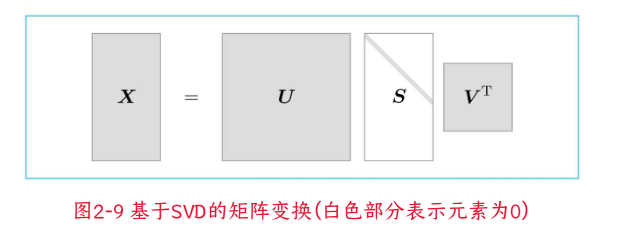


在式（2.7）中，U是正交矩阵。这个正交矩阵构成了一些空间中的基轴（基向量）​，我们可以将矩阵U作为“单词空间”​。S是对角矩阵，奇异值在对角线上降序排列。简单地说，我们可以将奇异值视为“对应的基轴”的重要性。这样一来，如图2-10所示，减少非重要元素就成为可能。

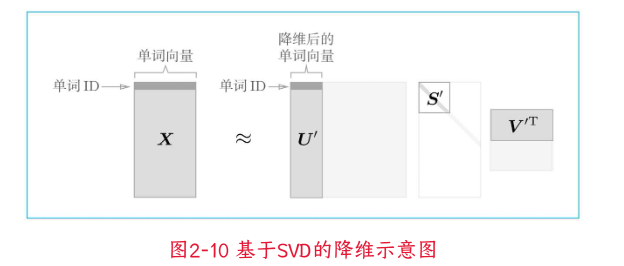


如图2-10所示，矩阵S的奇异值小，对应的基轴的重要性低，因此，可以通过去除矩阵U中的多余的列向量来近似原始矩阵。用我们正在处理的“单词的PPMI矩阵”来说明的话，矩阵X的各行包含对应的单词ID的单词向量，这些单词向量使用降维后的矩阵U′表示。

单词的共现矩阵是正方形矩阵，但在图2-10中，为了和之前的图一致，画的是长方形。另外，这里对SVD的介绍仅限于最直观的概要性的说明。想从数学角度仔细理解的读者，请参考文献[20]等。

### 基于SVD的降维


接下来，我们使用Python来实现SVD，这里可以使用NumPy的linalg模块中的svd方法。linalg是linear algebra（线性代数）的简称。下面，我们创建一个共现矩阵，将其转化为PPMI矩阵，然后对其进行SVD

In [4]:
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from common.util import preprocess, create_co_matrix, ppmi

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(id_to_word)
C = create_co_matrix(corpus, vocab_size, window_size=1)
W = ppmi(C)
# SVD
U, S, V = np.linalg.svd(W)

SVD执行完毕。上面的变量U包含经过SVD转化的密集向量表示。现在，我们来看一下它的内容。单词ID为0的单词向量如下。

In [7]:
print(C[0])# 共现矩阵

print(W[0])# PPMI矩阵

print(U[0])# SVD

[0 1 0 0 0 0 0]
[0.    1.807 0.    0.    0.    0.    0.   ]
[ 0.000e+00  3.409e-01 -1.205e-01 -3.331e-16 -1.110e-16 -9.323e-01
 -2.426e-17]


如上所示，原先的稀疏向量W[0]经过SVD被转化成了密集向量U[0]​。如果要对这个密集向量降维，比如把它降维到二维向量，取出前两个元素即可。

In [9]:
print(U[0,:2])

[0.    0.341]


这样我们就完成了降维。现在，我们用二维向量表示各个单词，并把它们画在图上，代码如下。

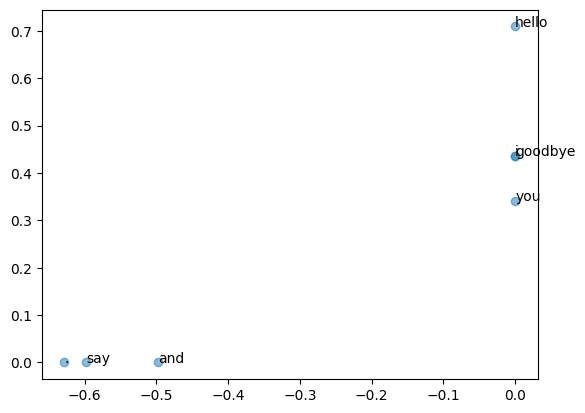

In [10]:
for word,word_id in word_to_id.items():
    plt.annotate(word,(U[word_id,0],U[word_id,1]))
    
plt.scatter(U[:,0],U[:,1],alpha=0.5)
plt.show()

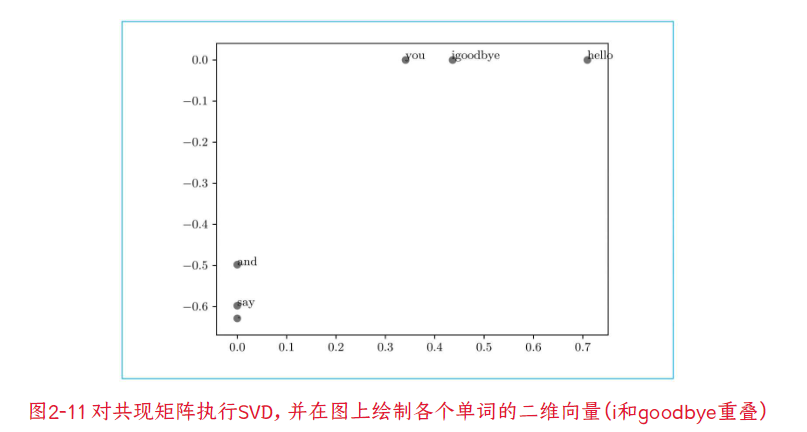

观察该图可以发现，goodbye和hello、you和i位置接近，这是比较符合我们的直觉的。但是，因为我们使用的语料库很小，有些结果就比较微妙。下面，我们将使用更大的PTB数据集进行相同的实验。首先，我们简单介绍一下PTB数据集。

如果矩阵大小是N,SVD的计算的复杂度将达到O（N3）​。这意味着SVD需要与N的立方成比例的计算量。因为现实中这样的计算量是做不到的，所以往往会使用Truncated SVD[21]等更快的方法。Truncated SVD通过截去（truncated）奇异值较小的部分，从而实现高速化。下一节，作为另一个选择，我们将使用sklearn库的Truncated SVD。

### PTB数据集

到目前为止，我们使用了非常小的文本数据作为语料库。这里，我们将使用一个大小合适的“真正的”语料库——Penn Treebank语料库（以下简称为PTB）​。

### Tip:PTB语料库

PTB语料库经常被用作评价提案方法的基准。本书中我们将使用PTB语料库进行各种实验。

我们使用的PTB语料库在word2vec的发明者托马斯·米科洛夫（Tomas Mikolov）的网页上有提供。这个PTB语料库是以文本文件的形式提供的，与原始的PTB的文章相比，多了若干预处理，包括将稀有单词替换成特殊字符< unk>（unk是unknown的简称）​，将具体的数字替换成“N”等。下面，我们将经过这些预处理之后的文本数据作为PTB语料库使用。作为参考，图2-12给出了PTB语料库的部分内容。

如图2-12所示，在PTB语料库中，一行保存一个句子。在本书中，我们将所有句子连接起来，并将其视为一个大的时序数据。此时，在每个句子的结尾处插入一个特殊字符< eos >（eos是end of sentence的简称）​。


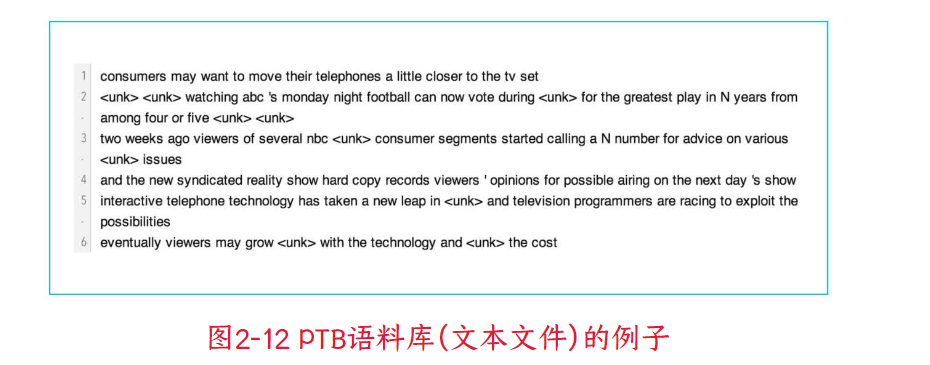

本书不考虑句子的分割，将多个句子连接起来得到的内容视为一个大的时序数据。当然，也可以以句子为单位进行处理，比如，以句子为单位计算词频。不过，考虑到简单性，本书不进行以句子为单位的处理。在本书中，为了方便使用Penn Treebank数据集，我们准备了专门的Python代码。这个文件在dataset/ptb.py中，并假定从章节目录（ch01、ch02、...）使用。比如，我们将当前目录移到ch02目录，并在这个目录中调用pythonshow_ptb.py。使用ptb.py的例子如下所示

In [11]:
import sys
sys.path.append('..')
from dataset import ptb

corpus, word_to_id, id_to_word = ptb.load_data('train')

print ('corpus size:', len(corpus))
print ('corpus[:30]:', corpus[:30])
print ()
print ('id_to_word[0]:', id_to_word[0])
print ('id_to_word[1]:', id_to_word[1])
print ('id_to_word[2]:', id_to_word[2])
print ()
print ("word_to_id['car']:", word_to_id['car'])
print ("word_to_id['happy']:", word_to_id['happy'])
print ("word_to_id['lexus']:", word_to_id['lexus'])

Done
corpus size: 929589
corpus[:30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

id_to_word[0]: aer
id_to_word[1]: banknote
id_to_word[2]: berlitz

word_to_id['car']: 3856
word_to_id['happy']: 4428
word_to_id['lexus']: 7426


语料库的用法和之前一样。corpus中保存了单词ID列表，id_to_word是将单词ID转化为单词的字典，word_to_id是将单词转化为单词ID的字典。

如上面的代码所示，使用ptb.load_data（​）加载数据。此时，指定参数’train'、'test’和’valid’中的一个，它们分别对应训练用数据、测试用数据和验证用数据中的一个。以上就是ptb.py文件的使用方法。

### 基于PTB数据集的评价

下面，我们将基于计数的方法应用于PTB数据集。这里建议使用更快速的SVD对大矩阵执行SVD，为此我们需要安装sklearn模块。当然，虽然仍可以使用基本版的SVD（np.linalg.svd（​）​）​，但是这需要更多的时间和内存。我们把源代码一并给出，如下所示


In [12]:
import sys
sys.path.append('..')
import numpy as np
from common.util import most_similar, create_co_matrix, ppmi
from dataset import ptb
window_size = 2
wordvec_size = 100

corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
print ('counting  co-occurrence ...')
C = create_co_matrix(corpus, vocab_size, window_size)
print ('calculating PPMI ...')
W = ppmi(C, verbose=True)

print ('calculating SVD ...')
try:
    # truncated SVD (fast!)
    from sklearn.utils.extmath import randomized_svd
    U, S, V = randomized_svd(W, n_components=wordvec_size, n_iter=5,random_state=None)
except ImportError:
    # SVD (slow)
    U, S, V = np.linalg.svd(W)

word_vecs = U[:, :wordvec_size]

querys = ['you', 'year', 'car', 'toyota']
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)

counting  co-occurrence ...
calculating PPMI ...


d:\Learning NLP Together\common\util.py:139: RuntimeWarning: overflow encountered in long_scalars
  pmi = np.log2(C[i, j] * N / (S[j]*S[i]) + eps)
d:\Learning NLP Together\common\util.py:139: RuntimeWarning: invalid value encountered in log2
  pmi = np.log2(C[i, j] * N / (S[j]*S[i]) + eps)


1.0% done
2.0% done
3.0% done
4.0% done
5.0% done
6.0% done
7.0% done
8.0% done
9.0% done
10.0% done
11.0% done
12.0% done
13.0% done
14.0% done
15.0% done
16.0% done
17.0% done
18.0% done
19.0% done
20.0% done
21.0% done
22.0% done
23.0% done
24.0% done
25.0% done
26.0% done
27.0% done
28.0% done
29.0% done
30.0% done
31.0% done
32.0% done
33.0% done
34.0% done
35.0% done
36.0% done
37.0% done
38.0% done
39.0% done
40.0% done
41.0% done
42.0% done
43.0% done
44.0% done
45.0% done
46.0% done
47.0% done
48.0% done
49.0% done
50.0% done
51.0% done
52.0% done
53.0% done
54.0% done
55.0% done
56.0% done
57.0% done
58.0% done
59.0% done
60.0% done
61.0% done
62.0% done
63.0% done
64.0% done
65.0% done
66.0% done
67.0% done
68.0% done
69.0% done
70.0% done
71.0% done
72.0% done
73.0% done
74.0% done
75.0% done
76.0% done
77.0% done
78.0% done
79.0% done
80.0% done
81.0% done
82.0% done
83.0% done
84.0% done
85.0% done
86.0% done
87.0% done
88.0% done
89.0% done
90.0% done
91.0% done
92.0% do

这里，为了执行SVD，我们使用了sklearn的randomized_svd（​）方法。该方法通过使用了随机数的Truncated SVD，仅对奇异值较大的部分进行计算，计算速度比常规的SVD快。剩余的代码和之前使用小语料库时的代码差不太多。执行代码，可以得以下结果（因为使用了随机数，所以在使用Truncated SVD的情况下，每次的结果都不一样）​。

观察结果可知，首先，对于查询词you，可以看到i、we等人称代词排在前面，这些都是在语法上具有相同用法的词。再者，查询词year有month、quarter等近义词，查询词car有auto、vehicle等近义词。此外，将toyota作为查询词时，出现了nissan、honda和lexus等汽车制造商名或者品牌名。像这样，在含义或语法上相似的单词表示为相近的向量，这符合我们的直觉。

我们终于成功地将单词含义编码成了向量，真是可喜可贺！使用语料库，计算上下文中的单词数量，将它们转化PPMI矩阵，再基于SVD降维获得好的单词向量。这就是单词的分布式表示，每个单词表示为固定长度的密集向量。在本章的实验中，我们只看了一部分单词的近义词，但是可以确认许多其他的单词也有这样的性质。期待使用更大的语料库可以获得更好的单词的分布式表示！